In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import pickle # saving and loading trained model
from os import path

# importing required libraries for normalizing data
from sklearn import preprocessing
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder,LabelEncoder, MinMaxScaler, OneHotEncoder)
from sklearn.preprocessing import Normalizer, MaxAbsScaler , RobustScaler, PowerTransformer

# importing library for plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
feature=["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
          "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells",
          "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
          "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count", 
          "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
          "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

In [81]:
train='data/nsl-kdd/KDDTrain+.txt'
test='data/nsl-kdd/KDDTest+.txt'
test21='data/nsl-kdd/KDDTest-21.txt'
train_data=pd.read_csv(train,names=feature)

In [82]:
train_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [83]:
# remove attribute 'difficulty_level'
train_data.drop(['difficulty'],axis=1,inplace=True)
train_data.shape

(125973, 42)

In [84]:
# number of attack labels 
train_data['label'].value_counts()

normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: label, dtype: int64

In [85]:
def change_label(df):
  df.label.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],'Dos',inplace=True)
  df.label.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'],'R2L',inplace=True)      
  df.label.replace(['ipsweep','mscan','nmap','portsweep','saint','satan'],'Probe',inplace=True)
  df.label.replace(['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],'U2R',inplace=True)

In [86]:
change_label(train_data)

In [87]:
# distribution of attack classes
train_data.label.value_counts()

normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: label, dtype: int64

In [88]:
data = train_data.copy()

In [89]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['protocol_type']= label_encoder.fit_transform(data['protocol_type'])
data['service']= label_encoder.fit_transform(data['service'])
data['flag']= label_encoder.fit_transform(data['flag'])
data['label']= label_encoder.fit_transform(data['label'])

data['protocol_type'].unique()
data['service'].unique()
data['flag'].unique()
data['label'].unique()

array([4, 0, 2, 1, 3], dtype=int64)

In [90]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,4
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,4
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,4
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4


In [91]:
X = data.drop(["label"],axis =1)
y = data["label"]

# CFS - Automatic Feature Selection

In [92]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif

In [93]:
selector = SelectPercentile(mutual_info_classif, percentile=30)
X_reduced = selector.fit_transform(X, y)
X_reduced.shape

(125973, 12)

In [94]:
cols = selector.get_support(indices=True)
selected_columns = X.iloc[:,cols].columns.tolist()
selected_columns

['service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'count',
 'serror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_serror_rate']

In [95]:
df = data[['service',
             'flag',
             'src_bytes',
             'dst_bytes',
             'count',
             'serror_rate',
             'same_srv_rate',
             'diff_srv_rate',
             'dst_host_srv_count',
             'dst_host_same_srv_rate',
             'dst_host_diff_srv_rate',
             'dst_host_serror_rate',
             'label']]
df.to_csv('nslkdd_processed.csv')

In [3]:
df = pd.read_csv('nslkdd_processed.csv')
df.head()

,Unnamed: 0,service,flag,src_bytes,dst_bytes,count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,label
0,0,20,9,491,0,2,0.0,1.00,0.00,25,0.17,0.03,0.00,4
1,1,44,9,146,0,13,0.0,0.08,0.15,1,0.00,0.60,0.00,4
2,2,49,5,0,0,123,1.0,0.05,0.07,26,0.10,0.05,1.00,0
3,3,24,9,232,8153,5,0.2,1.00,0.00,255,1.00,0.00,0.03,4
4,4,24,9,199,420,30,0.0,1.00,0.00,255,1.00,0.00,0.00,4


In [4]:
del df['Unnamed: 0']

In [5]:
df = df[0:50000]

In [6]:
df['label'].value_counts()

4    26555
0    18335
1     4660
2      427
3       23
Name: label, dtype: int64

In [24]:
# changing attack labels to their respective attack class
def change_label(df):
    df.label.replace([0,1,2,3],1,inplace=True)
    df.label.replace([4],0,inplace=True)
     

In [25]:
change_label(df)

In [26]:
df.to_csv('processed.csv')

In [27]:
X = df.drop(["label"],axis =1)
y = df["label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((40000, 12), (40000,), (10000, 12), (10000,))

In [29]:
X_train.to_csv('x.csv')
y_train.to_csv('y.csv')

In [30]:
ML_Model = []
accuracy = []
f1score = []
recall = []
precision = []
fpr = []

#function to call for storing the results
def storeResults(model, a,b,c,d,e):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))    
    f1score.append(round(d, 3))
    fpr.append(round(e, 3))

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ANN

In [32]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier()

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann_acc = accuracy_score(y_hat, y_test)
ann_prec = precision_score(y_hat, y_test,average='weighted')
ann_rec = recall_score(y_hat, y_test,average='weighted')
ann_f1 = f1_score(y_hat, y_test,average='weighted')
ann_fpr = 1 - ann_acc

In [43]:
storeResults('ANN',ann_acc,ann_prec,ann_rec,ann_f1,ann_fpr)

# Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model 
rf = RandomForestClassifier(random_state=10)

# fit the model 
rf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')
rf_fpr = 1 - rf_acc

In [44]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1,rf_fpr)

# Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
dt = DecisionTreeClassifier(random_state=10)

# fit the model 
dt.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_pred, y_test)
dt_prec = precision_score(y_pred, y_test,average='weighted')
dt_rec = recall_score(y_pred, y_test,average='weighted')
dt_f1 = f1_score(y_pred, y_test,average='weighted')
dt_fpr = 1 - dt_acc

In [45]:
storeResults('Decision Tree',dt_acc,dt_prec,dt_rec,dt_f1,dt_fpr)

# SVM

In [38]:
from sklearn.svm import SVC

# instantiate the model 
svm = SVC()

# fit the model 
svm.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_pred, y_test)
svm_prec = precision_score(y_pred, y_test,average='weighted')
svm_rec = recall_score(y_pred, y_test,average='weighted')
svm_f1 = f1_score(y_pred, y_test,average='weighted')
svm_fpr = 1 - svm_acc

In [46]:
storeResults('SVM',svm_acc,svm_prec,svm_rec,svm_f1,svm_fpr)

# Voting Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

rfc = RandomForestClassifier()
parameters = {
    "n_estimators":[250],
    "max_depth":[200]
    
}

from sklearn.model_selection import GridSearchCV
forest = GridSearchCV(rfc,parameters,cv=10)

clf2 = DecisionTreeClassifier(random_state=100)

eclf1 = VotingClassifier(estimators=[('rf-parameter', forest), ('dt', clf2)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

In [57]:
storeResults('Voting Classifier',vot_acc,vot_prec,vot_rec,vot_f1,1-vot_acc)

# Stacking Classifier

In [41]:
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier

estimators = [('rf', forest),('mlp', MLPClassifier(random_state=1, max_iter=3000))]

clf = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=1000))


clf.fit(X_train,y_train)

y_pred = clf.predict(X_train)

stac_acc = accuracy_score(y_pred, y_train)
stac_prec = precision_score(y_pred, y_train,average='weighted')
stac_rec = recall_score(y_pred, y_train,average='weighted')
stac_f1 = f1_score(y_pred, y_train,average='weighted')

In [58]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1,1-stac_acc)

# Comparison

In [59]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score,
                       'FPR': fpr
                      })

In [60]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score,FPR
0,ANN,0.957,0.957,0.957,0.957,0.043
1,Random Forest,0.998,0.998,0.998,0.998,0.002
2,Decision Tree,0.998,0.998,0.998,0.998,0.002
3,SVM,0.529,1.000,0.529,0.691,0.471
4,Voting Classifier,0.998,0.998,0.998,0.998,0.002
5,Stacking Classifier,1.000,1.000,1.000,1.000,0.000


# Modelling

In [61]:
import joblib
#filename = 'model.sav'
joblib.dump(clf, 'model_nsl.sav')

['model_nsl.sav']

# Graph

In [62]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# ACcuracy

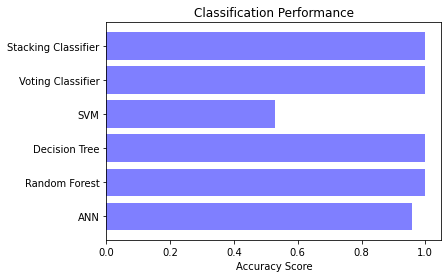

In [63]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

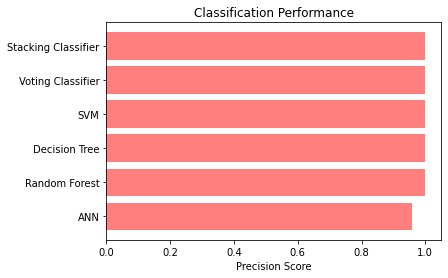

In [64]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

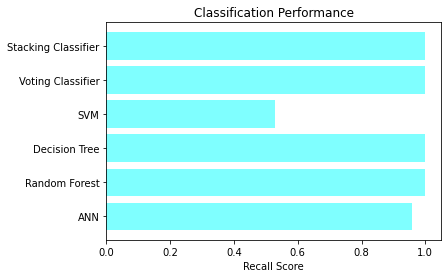

In [65]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='cyan')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 SCore

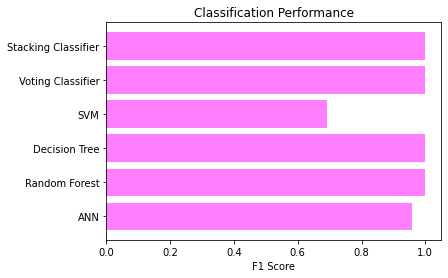

In [66]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# FPR

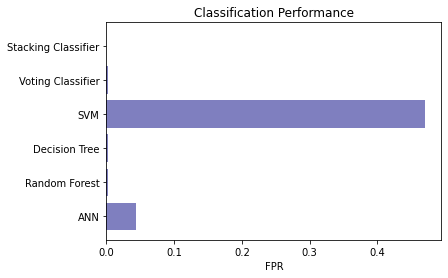

In [67]:
plt2.barh(y_pos, fpr, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('FPR')
plt2.title('Classification Performance')
plt2.show()

# Prediction

In [4]:
import joblib

In [5]:
model1 = joblib.load('model_nsl.sav')

In [10]:
int_fea = [49,1,0,0,121,0,0.16,0.06,19,0.07,0.07,0]
final4=[np.array(int_fea)]

In [11]:
predict1 = model1.predict(final4)

In [12]:
if  predict1==0:
    output = 'There is an Attack Detected, Attack Type is DoS!'
elif predict1 == 1:
    output = 'There is an Attack Detected, Attack Type is Probe!'
elif predict1 == 2:
    output = 'There is an Attack Detected, Attack Type is R2L!'
elif predict1 == 3:
    output = 'There is an Attack Detected, Attack Type is U2R!'
elif predict==4:
    output = 'There is no Attack Detected, it is Normal!'

In [13]:
print(output)

There is an Attack Detected, Attack Type is Probe!
